In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import colorcet as cc
import warnings
import re
import math
from scipy.stats import norm
from norm import cut_norm,interpolate_and_sample

def readsheet(sheetname,excel_file_path):
    data = pd.read_excel(excel_file_path,sheet_name=sheetname)
    columns_to_remove = ['Temp. [°C]']
    data.drop(columns=columns_to_remove, inplace=True)
    return data

In [2]:
#SUM ALL THE DATA
excel_file_path = 'WT_in_LB_data_Omar_s1.XLSX'
lsheetnames = ['P0002','P0005','P0008','P0012','P0030']
numbers=[0,1,2,3,4]
excel_file_path2 = 'different_conditions_data_Omar_s2.XLSX'
lsheetnames2 = ['P12_WT','P13_TolC_KO','P16_AcrD_KO','P17_AcrA_KO','P18_AcrB_KO','P24_AcrBD_KO']
numbers2=[0,1,2,3,4,5]
split = [n.split('_') for n in lsheetnames2]
gene= [sublist[1] for sublist in split]         #The strain: WT,AcrA,AcrB,etc...
custom_palette=sns.color_palette(cc.glasbey) 
lsheetnames3 = ['P25_kan_2_50','P27_kan_1_25','P28_kan','P30_kan_2_50']
numbers3=[0,1,2,3]

legend_added = set()  # To keep track of colors for which legend entry is added
time_to_cut=175000
nvalues_to_interpolate=299
sum_data=pd.DataFrame()
sum_data2=pd.DataFrame()
sum_data3=pd.DataFrame()
batches=[]
batch_color_map = {}
color_index = 0
experiments=[]               

# Suppress PerformanceWarning from pandas
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

for sheetname,i in zip(lsheetnames,numbers):
    df = readsheet(sheetname, excel_file_path)
    df=cut_norm(df,time_to_cut)
    df = interpolate_and_sample(df,time_to_cut,nvalues_to_interpolate)
    Time=df['Time [s]'].values
    for column,j in zip(df.columns.values[2:],enumerate(df.columns.values[2:])):
        new_column_name = f'WT_LB_{i}_{j[0]}'
        sum_data[new_column_name]=df[column]
        batch=f'WT_LB_{i}'
        batches.append(batch)
        for batch_ in batches:
            if batch_ not in batch_color_map:
                batch_color_map[batch_] = custom_palette[color_index]
                color_index = (color_index + 1) % len(custom_palette)
        color = batch_color_map[batch]
        # Add legend entry only if the color is not yet added to the legend
        if color not in legend_added:
            legend_added.add(color)  
            experiments.append(batch)

for sheetname2,i in zip(lsheetnames2,numbers2):
    df = readsheet(sheetname2,excel_file_path2)
    df=cut_norm(df,time_to_cut)
    df = interpolate_and_sample(df,time_to_cut,nvalues_to_interpolate)
    split_column_names = [name.split('_') for name in df.columns.values[2:]]
    drugs=[sublist[0] for sublist in split_column_names]
    plate_indexes=[sublist[1] for sublist in split_column_names]
    sum_split=[name.split('_') for name in sum_data.columns]
    joined_sum_split = ['_'.join(parts[:3]) for parts in sum_split]
    for column,drug,plate_index in zip(df.columns.values[2:],drugs,plate_indexes):
        aux=0
        for j in range (len(joined_sum_split)):
            if joined_sum_split[j]==f'{gene[i]}_{drug}_{aux}':
                aux+=1    
        new_column_name = f'{gene[i]}_{drug}_{aux}_{plate_index}'
        sum_data2[new_column_name]=df[column]
        batch=f'{gene[i]}_{drug}_{aux}'
        batches.append(batch)
        for batch_ in batches:
            if batch_ not in batch_color_map:
                batch_color_map[batch_] = custom_palette[color_index]
                color_index = (color_index + 1) % len(custom_palette)
        color = batch_color_map[batch]
        if color not in legend_added:
            legend_added.add(color)  
            experiments.append(batch)

for sheetname3 in lsheetnames3:
    df = readsheet(sheetname3,excel_file_path2)
    df=cut_norm(df,time_to_cut)
    df = interpolate_and_sample(df,time_to_cut,nvalues_to_interpolate)
    split_column_names = [name.split('_') for name in df.columns.values[2:]]
    strain_drugs=['_'.join(parts[:2]) for parts in split_column_names]
    plate_indexes=[sublist[2] for sublist in split_column_names]
    sum_split=[name.split('_') for name in sum_data.columns]
    joined_sum_split = ['_'.join(parts[:3]) for parts in sum_split]
    sum_split2=[name.split('_') for name in sum_data2.columns]
    joined_sum_split2 = ['_'.join(parts2[:3]) for parts2 in sum_split2]
    sum_split3=[name.split('_') for name in sum_data3.columns]
    joined_sum_split3 = ['_'.join(parts[:3]) for parts in sum_split3]
    for column,strain_drug,plate_index in zip(df.columns.values[2:],strain_drugs,plate_indexes):
        aux=0
        for j in range (len(joined_sum_split)):
            if joined_sum_split[j]==f'{strain_drug}_{aux}':
                aux+=1   
        for k in range (len(joined_sum_split2)):
            if joined_sum_split2[k]==f'{strain_drug}_{aux}':
                aux+=1 
        for l in range (len(joined_sum_split3)):
            if joined_sum_split3[l]==f'{strain_drug}_{aux}':
                aux+=1       
        new_column_name = f'{strain_drug}_{aux}_{plate_index}'
        sum_data3[new_column_name]=df[column]
        batch=f'{strain_drug}_{aux}'
        batches.append(batch)
        for batch in batches:
            if batch not in batch_color_map:
                batch_color_map[batch] = custom_palette[color_index]
                color_index = (color_index + 1) % len(custom_palette)
        color = batch_color_map[batch]
        if color not in legend_added:
            legend_added.add(color)  
            experiments.append(batch)

total_data = pd.concat([sum_data, sum_data2,sum_data3], axis=1)

In [3]:
# Function to extract numbers for K and M
def extract_k_m(s):
    # Use regular expressions to find 'K' followed by a number and 'M' followed by a number
    k_match = re.search(r'K(\d+(\.\d+)?)', s)  # Matches 'K' followed by a number
    m_match = re.search(r'M(\d+(\.\d+)?)', s)  # Matches 'M' followed by a number
    
    # Extract the matched numbers, or 0 if not found
    k_value = float(k_match.group(1)) if k_match else 0
    m_value = float(m_match.group(1)) if m_match else 0
    
    return [k_value, m_value]

# Function to create a binary array for presence of each target
def binary_presence(s):
    # Target elements to check
    strain_types = ['WT', 'TolC', 'AcrD', 'AcrA', 'AcrB', 'AcrBD', 'AcrE', 'AcrF']
    return [1 if target == s else 0 for target in strain_types]


In [4]:
split_batches=[name.split('_') for name in batches]
raw_strains=[sublist[0] for sublist in split_batches]
raw_drugs=[sublist[1] for sublist in split_batches]

print(len(batches),batches)
print(len(raw_strains),raw_strains)
print(len(raw_drugs),raw_drugs)

result2 = [extract_k_m(item) for item in raw_drugs]
result = [binary_presence(item) for item in raw_strains]
df= pd.DataFrame(result).T
df2= pd.DataFrame(result2).T
print(df.shape,df)
print(df2.shape,df2)

with open("output_data.txt", "w") as file:
    # Write batches
    file.write("Batches:\n")
    file.write(str(batches) + "\n\n")
    
    # Write raw strains and drugs
    file.write("Raw Strains:\n")
    file.write(str(raw_strains) + "\n\n")
    
    file.write("Raw Drugs:\n")
    file.write(str(raw_drugs) + "\n\n")
    
    # Write df DataFrame
    file.write("DataFrame df:\n")
    file.write(df.to_string() + "\n\n")
    
    # Write df2 DataFrame
    file.write("DataFrame df2:\n")
    file.write(df2.to_string() + "\n")

print("Data has been written to output_data.txt")
# print(batches[489],raw_strains[489],raw_drugs[489],'\n',df[:][489],'\n',df2[:][489])

816 ['WT_LB_0', 'WT_LB_0', 'WT_LB_0', 'WT_LB_0', 'WT_LB_0', 'WT_LB_0', 'WT_LB_0', 'WT_LB_0', 'WT_LB_0', 'WT_LB_0', 'WT_LB_0', 'WT_LB_0', 'WT_LB_0', 'WT_LB_0', 'WT_LB_0', 'WT_LB_1', 'WT_LB_1', 'WT_LB_1', 'WT_LB_1', 'WT_LB_1', 'WT_LB_2', 'WT_LB_2', 'WT_LB_2', 'WT_LB_2', 'WT_LB_3', 'WT_LB_3', 'WT_LB_3', 'WT_LB_3', 'WT_LB_3', 'WT_LB_4', 'WT_LB_4', 'WT_LB_4', 'WT_LB_4', 'WT_LB_4', 'WT_LB_4', 'WT_LB_4', 'WT_LB_4', 'WT_LB_4', 'WT_LB_4', 'WT_LB_4', 'WT_LB_4', 'WT_K1.25_0', 'WT_K1.25_0', 'WT_K1.25_0', 'WT_K1.25_0', 'WT_K1.25_0', 'WT_K1.25_0', 'WT_K2.50_0', 'WT_K2.50_0', 'WT_K2.50_0', 'WT_K2.50_0', 'WT_K2.50_0', 'WT_K2.50_0', 'WT_K3.75_0', 'WT_K3.75_0', 'WT_K3.75_0', 'WT_K3.75_0', 'WT_K3.75_0', 'WT_K3.75_0', 'WT_M0.25_0', 'WT_M0.25_0', 'WT_M0.25_0', 'WT_M0.25_0', 'WT_M0.25_0', 'WT_M0.25_0', 'WT_M0.50_0', 'WT_M0.50_0', 'WT_M0.50_0', 'WT_M0.50_0', 'WT_M0.50_0', 'WT_M0.50_0', 'WT_M1.00_0', 'WT_M1.00_0', 'WT_M1.00_0', 'WT_M1.00_0', 'WT_M1.00_0', 'WT_M1.00_0', 'WT_K1.25&M0.25_0', 'WT_K1.25&M0.25_0', 

In [ ]:
#Reorder the data by drugs/strains
train_data=pd.DataFrame()
test_data=pd.DataFrame()
drug_conditions_test=pd.DataFrame()
strain_conditions_test=pd.DataFrame()
drug_conditions_train=pd.DataFrame()
strain_conditions_train=pd.DataFrame()
batches_test=[]
batches_train=[]
np.random.seed(4)

columns=total_data.columns[:]
num_list = list(range(len(batches)))

experiments2=[]
split_experiments=[name.split('_') for name in experiments]
exp=0       #[1] for drugs, [0] for strain
experimentos=[sublist[exp] for sublist in split_experiments]
batches2=[]
parts=[name.split('_') for name in batches]
batches2=[sublist[exp] for sublist in parts]      
print(len(batches2))

for experimento in experimentos:
    if experimento not in experiments2:
        experiments2.append(experimento)

print(len(experiments2),experiments2)

#Select the test_data and the train_data, 15% splitting
for experiment in experiments2:
    columns_to_select=[]
    for batch,i in zip(batches2,num_list):
        if batch==experiment:
            columns_to_select.append(columns[i])
    #print(experiment,len(columns_to_select))              
    num_columns_to_select = int(len(columns_to_select) * 0.15)        
    test_columns = np.random.choice(columns_to_select, num_columns_to_select,replace=False)
    batches_test.extend([experiment] * len(test_columns))
    test_columns_data = total_data[test_columns]
    test_data = pd.concat([test_data, test_columns_data], axis=1)

    #Get the test conditions vectors (for drugs and strains)
    split_test_columns=[name.split('_') for name in test_columns]
    raw_strains=[sublist[0] for sublist in split_test_columns]
    raw_drugs=[sublist[1] for sublist in split_test_columns]
    strain_vector = [binary_presence(item) for item in raw_strains]
    drug_vector = [extract_k_m(item) for item in raw_drugs]
    df= pd.DataFrame(strain_vector)
    df2= pd.DataFrame(drug_vector)
    strain_conditions_test = pd.concat([strain_conditions_test, df], axis=0)
    drug_conditions_test = pd.concat([drug_conditions_test, df2], axis=0)

    train_columns = [col for col in columns_to_select if col not in test_columns]
    print(len(test_columns),len(columns_to_select),num_columns_to_select,len(train_columns)+len(test_columns))
    train_columns_data = total_data[train_columns]
    train_data = pd.concat([train_data, train_columns_data], axis=1)
    batches_train.extend([experiment] * len(train_columns))

    #Get the train conditions vectors (for drugs and strains)
    split_train_columns=[name.split('_') for name in train_columns]
    raw_strains=[sublist[0] for sublist in split_train_columns]
    raw_drugs=[sublist[1] for sublist in split_train_columns]
    strain_vector = [binary_presence(item) for item in raw_strains]
    drug_vector = [extract_k_m(item) for item in raw_drugs]
    df= pd.DataFrame(strain_vector)
    df2= pd.DataFrame(drug_vector)
    strain_conditions_train = pd.concat([strain_conditions_train, df], axis=0)
    drug_conditions_train = pd.concat([drug_conditions_train, df2], axis=0)

#print(test_data.shape,train_data.shape)
print('The number of total growth curves is:',len(batches_test),len(batches_train))         

train_data_T=train_data.T
test_data_T=test_data.T
X_train3=train_data_T.values
X_test3=test_data_T.values
X_train_tensor3 = torch.FloatTensor(X_train3)
X_test_tensor3 = torch.FloatTensor(X_test3)
C_test_tensor = torch.FloatTensor(pd.concat([strain_conditions_test, drug_conditions_test], axis=1).values)        #Conditions tensor (strain+drug vectors), to introduce it as input to the CVAE
C_train_tensor = torch.FloatTensor(pd.concat([strain_conditions_train, drug_conditions_train], axis=1).values)

print(test_data_T.shape,strain_conditions_test.shape,drug_conditions_test.shape,train_data_T.shape,strain_conditions_train.shape,drug_conditions_train.shape,C_test_tensor.shape)
custom_palette=sns.color_palette(cc.glasbey,len(batches_test)) 

816
8 ['WT', 'TolC', 'AcrD', 'AcrA', 'AcrB', 'AcrBD', 'AcrE', 'AcrF']
31 210 31 210
23 155 23 155
16 107 16 107
16 107 16 107
16 107 16 107
8 58 8 58
5 36 5 36
5 36 5 36
The number of total growth curves is: 120 696
(120, 100) (120, 8) (120, 2) (696, 100) (696, 8) (696, 2) torch.Size([120, 10])


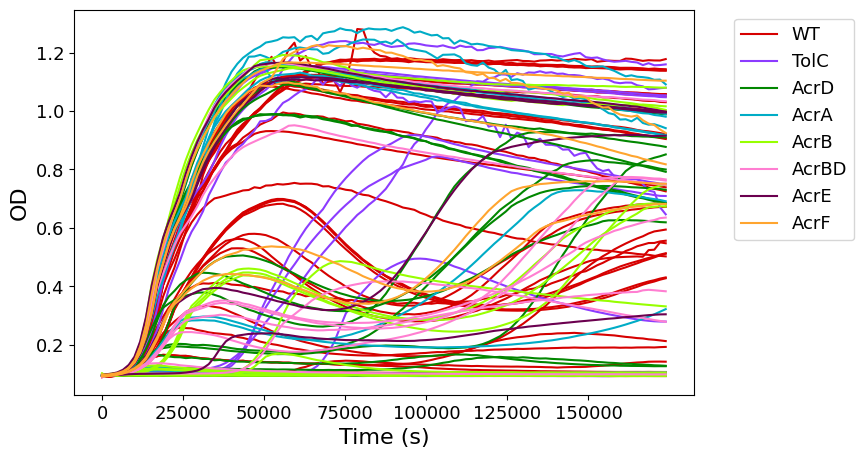

In [6]:
fig, ax = plt.subplots(1,1,figsize=[8,5])
custom_palette=sns.color_palette(cc.glasbey,len(experiments2)) 

total_data['Time [s]'] = Time
test_data['Time [s]'] = Time
train_data['Time [s]'] = Time
legend_added = set()  
batch_color_map = {}
color_index = 0
for batch in batches2:
    if batch not in batch_color_map:
        batch_color_map[batch] = custom_palette[color_index]
        color_index = (color_index + 1) % len(custom_palette)

for column,batch in zip(test_data.columns.values[:len(batches_test)],batches_test):
    color = batch_color_map[batch]
    if color not in legend_added:
        sns.lineplot(data=test_data, x=test_data['Time [s]'], y=column,ax=ax,color=color,label=batch)
        legend_added.add(color)  # Add the color to the set to indicate the legend entry is added
    else:
        sns.lineplot(data=test_data, x=test_data['Time [s]'], y=column,ax=ax,color=color)

# for column,batch in zip(total_data.columns.values[:len(batches2)],batches2):
#     color = batch_color_map[batch]
#     if(batch=='K1.25'):
#         if color not in legend_added:
#             sns.lineplot(data=total_data, x=total_data['Time [s]'], y=column,ax=ax,color=color,label=batch)
#             legend_added.add(color)  # Add the color to the set to indicate the legend entry is added
#         else:
#             sns.lineplot(data=total_data, x=total_data['Time [s]'], y=column,ax=ax,color=color)

plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('OD', fontsize=16)
ax.set_xticks(range(0, 175000, 25000))
ax.tick_params(axis='both', which='major', labelsize=13)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 13})
#plt.tight_layout()  # Adjust layout to make room for the legend
plt.show()


In [7]:
class CVAE(nn.Module):
    def __init__(self, input_dim, latent_dim, num_hidden_layers, hidden_dims, condition_dim):
        super(CVAE, self).__init__()
        
        # Construct the encoder
        encoder_layers = []
        prev_dim = input_dim + condition_dim
        for i in range(num_hidden_layers):
            encoder_layers.append(nn.Linear(prev_dim, hidden_dims[i]))
            encoder_layers.append(nn.Sigmoid())
            prev_dim = hidden_dims[i]
        
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Mean and log variance layers
        self.mean_layer = nn.Linear(hidden_dims[-1], latent_dim)
        self.logvar_layer = nn.Linear(hidden_dims[-1], latent_dim)
        
        # Construct the decoder
        decoder_layers = []
        prev_dim = latent_dim + condition_dim
        for i in reversed(range(num_hidden_layers)):
            decoder_layers.append(nn.Linear(prev_dim, hidden_dims[i]))
            decoder_layers.append(nn.Sigmoid())
            prev_dim = hidden_dims[i]
        
        decoder_layers.append(nn.Linear(hidden_dims[0], input_dim))
        
        self.decoder = nn.Sequential(*decoder_layers)
         
    def encode(self, x, c):
        # Concatenate input data with condition
        x = torch.cat([x, c], dim=1)  # Concatenate along feature dimension
        x = self.encoder(x)
        mean, logvar = self.mean_layer(x), self.logvar_layer(x)
        return mean, logvar

    def reparameterization(self, mean, logvar):
        epsilon = torch.randn_like(logvar)   
        z = mean + torch.exp(logvar * 0.5) * epsilon   
        return z

    def decode(self, z, c):
        # Concatenate latent variable with condition
        z = torch.cat([z, c], dim=1)  # Concatenate along feature dimension
        return self.decoder(z)

    def forward(self, x, c):
        # Forward pass now takes in x and c
        mean, logvar = self.encode(x, c)
        z = self.reparameterization(mean, logvar)
        x_hat = self.decode(z, c)
        return x_hat, mean, logvar    

def loss_function(x, x_hat, mean, log_var,alpha):
    reproduction_loss =nn.MSELoss()(x,x_hat)
    KLD = (- 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp()))/ (x.shape[0])
    aux=reproduction_loss.detach().numpy()
    return reproduction_loss + alpha*KLD,aux

In [8]:
torch.manual_seed(42)
trained_models = []

input_dim = X_train3.shape[1]  # Number of input features
condition_dim= 8+2 # Strain and drug dimension vectors
latent_dim = 2  # Desired number of output dimensions
num_hidden_layers=3
hidden_layers=[64,32,16]      #From bigger to smaller
model = CVAE(input_dim, latent_dim,num_hidden_layers,hidden_layers,condition_dim)
alpha=5E-5  #5E-5
str_alpha="{:.0E}".format(alpha)


# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1E-2)     #Optimizer algorithm, lr: learning rate 1E-2 

# Training the autoencoder
num_epochs = 30000          #Number of 'jumps' 30000
train_losses = []
test_losses = []
mse_test=0
for epoch in range(num_epochs):
   # Training phase
   x_hat, mean, log_var = model(X_train_tensor3,C_train_tensor)            # Forward pass
   train_loss,_ = loss_function(X_train_tensor3, x_hat, mean, log_var,alpha)

   # Backward pass and optimization, in fact this is the training of the parameters of the model
   optimizer.zero_grad()         #In this way the gradient is not cumulative
   train_loss.backward()             #The gradients (derivatives) of the parameters to optimize (points of the growth) 
   optimizer.step()              #Actualize the optimizer(do the step of the optimizer), in the case of the Adam it multiplies the new vector by the lr

   train_losses.append(train_loss.item())  # Append train loss
   
   with torch.no_grad():  # Disable gradient calculation for the test evaluation
      x_hat, mean, log_var = model(X_test_tensor3,C_test_tensor)            # Forward pass
      test_loss,mse_test = loss_function(X_test_tensor3, x_hat, mean, log_var,alpha)
   print(f"Total test Loss: {test_loss.detach().numpy():.2e}, MSE Test: {mse_test:.2e}")
   test_losses.append(test_loss.item())  # Append test loss
trained_models.append(model)
#torch.save(model.state_dict(), 'saved_models/VAE_n1000_alpha{str_alpha[0]}E{str_alpha[4]}lr5E4_v3.pth')
print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

Total test Loss: 2.57e-01, MSE Test: 2.57e-01
Total test Loss: 1.78e-01, MSE Test: 1.78e-01
Total test Loss: 1.85e-01, MSE Test: 1.85e-01
Total test Loss: 2.10e-01, MSE Test: 2.10e-01
Total test Loss: 2.15e-01, MSE Test: 2.15e-01
Total test Loss: 2.02e-01, MSE Test: 2.02e-01
Total test Loss: 1.85e-01, MSE Test: 1.85e-01
Total test Loss: 1.70e-01, MSE Test: 1.70e-01
Total test Loss: 1.63e-01, MSE Test: 1.63e-01
Total test Loss: 1.59e-01, MSE Test: 1.59e-01
Total test Loss: 1.59e-01, MSE Test: 1.59e-01
Total test Loss: 1.58e-01, MSE Test: 1.58e-01
Total test Loss: 1.56e-01, MSE Test: 1.56e-01
Total test Loss: 1.54e-01, MSE Test: 1.54e-01
Total test Loss: 1.53e-01, MSE Test: 1.53e-01
Total test Loss: 1.52e-01, MSE Test: 1.52e-01
Total test Loss: 1.52e-01, MSE Test: 1.52e-01
Total test Loss: 1.53e-01, MSE Test: 1.53e-01
Total test Loss: 1.54e-01, MSE Test: 1.54e-01
Total test Loss: 1.54e-01, MSE Test: 1.54e-01
Total test Loss: 1.53e-01, MSE Test: 1.53e-01
Total test Loss: 1.50e-01, MSE Tes

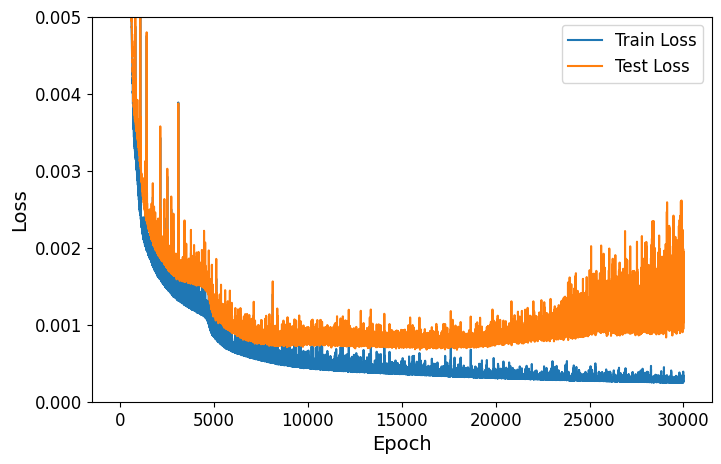

In [9]:
fig, ax = plt.subplots(1,1,figsize=[8,5])
#plt.title('Train and Test Loss over Epochs')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
epochs = range(1, num_epochs + 1)

sns.lineplot(x=epochs, y=train_losses, label='Train Loss',ax=ax)
sns.lineplot(x=epochs, y=test_losses, label='Test Loss',ax=ax)
ax.set_ylim(0, 0.005)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(fontsize=12)

120 (100, 121)


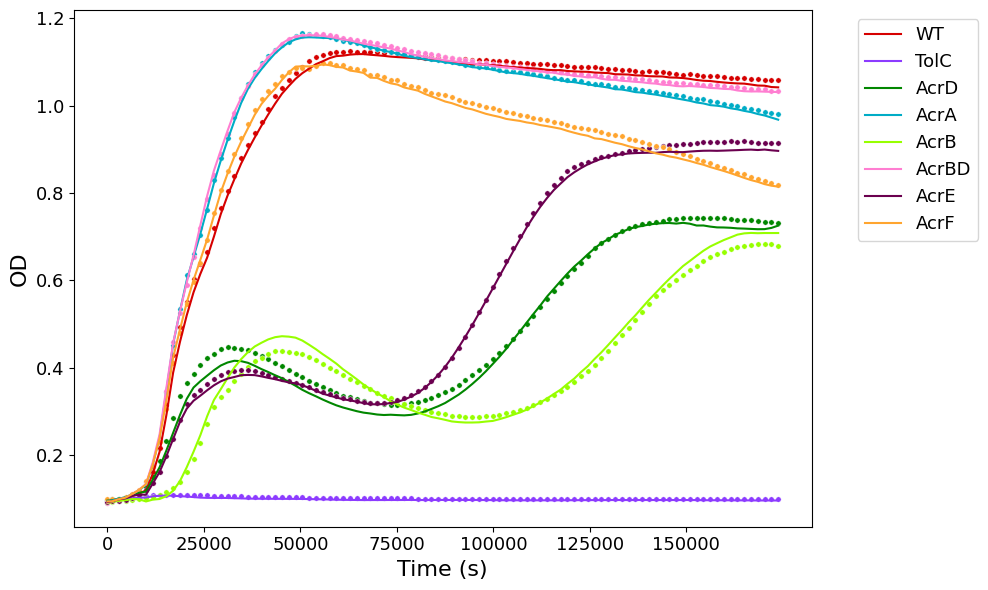

In [10]:
#Plotting the decoded vectors
fig, ax = plt.subplots(1,1,figsize=[10,6])
custom_palette=sns.color_palette(cc.glasbey,len(experiments2))

model=trained_models[0]
print(len(batches_test),test_data.shape)        
columns2=test_data.columns[:len(batches_test)]
num_list2 = list(range(len(batches_test)))
test_data2=pd.DataFrame()
drug_conditions_test2=pd.DataFrame()
strain_conditions_test2=pd.DataFrame()
batches_test2=[]
np.random.seed(4)

#take only one curve from each experiment to not overcharge the plot
for experiment in experiments2:
    columns_to_select=[]
    for batch,i in zip(batches_test,num_list2):
        if batch==experiment:
            columns_to_select.append(columns2[i])    
    test_columns = np.random.choice(columns_to_select,1,replace=False)
    batches_test2.append(experiment)
    test_columns_data = total_data[test_columns]
    # print(len(test_columns),len(columns_to_select),batches_test2)
    test_data2 = pd.concat([test_data2, test_columns_data], axis=1)

    #Get the test conditions vectors (for drugs and strains)
    split_test_columns=[name.split('_') for name in test_columns]
    raw_strains=[sublist[0] for sublist in split_test_columns]
    raw_drugs=[sublist[1] for sublist in split_test_columns]
    strain_vector = [binary_presence(item) for item in raw_strains]
    drug_vector = [extract_k_m(item) for item in raw_drugs]
    df= pd.DataFrame(strain_vector)
    df2= pd.DataFrame(drug_vector)
    strain_conditions_test2 = pd.concat([strain_conditions_test2, df], axis=0)
    drug_conditions_test2 = pd.concat([drug_conditions_test2, df2], axis=0)



#transform the subset test in a tensor, encode it and decode it
test_data2_T=test_data2.T
X_test4=test_data2_T.values
X_test_tensor4 = torch.FloatTensor(X_test4)
C_test_tensor2 = torch.FloatTensor(pd.concat([strain_conditions_test2, drug_conditions_test2], axis=1).values)        #Conditions tensor (strain+drug vectors), to introduce it as input to the CVAE

test_mean,test_logvar = model.encode(X_test_tensor4,C_test_tensor2)
test_mean = test_mean.detach().numpy()
test_logvar = test_logvar.detach().numpy()

decoded_test2 = model.decode(torch.FloatTensor(test_mean),C_test_tensor2).detach().numpy()
decoded_test2_df=pd.DataFrame(decoded_test2).T

decoded_test2_df['Time [s]'] = Time
test_data2['Time [s]'] = Time
 

for column,column2,color,batch in zip(decoded_test2_df.columns.values[:len(batches_test2)],test_data2.columns.values[:len(batches_test2)], custom_palette,batches_test2):
    sns.lineplot(data=decoded_test2_df, x='Time [s]', y=column, ax=ax, color=color, label=batch)
    sns.scatterplot(data=test_data2, x='Time [s]', y=column2, ax=ax, color=color,s=15)

plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('OD', fontsize=16)
ax.set_xticks(range(0, 175000, 25000))
ax.tick_params(axis='both', which='major', labelsize=13)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 13})
plt.tight_layout()  # Adjust layout to make room for the legend
plt.show()



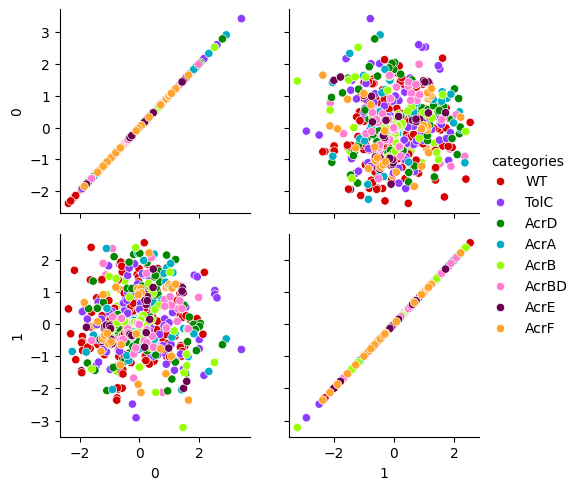

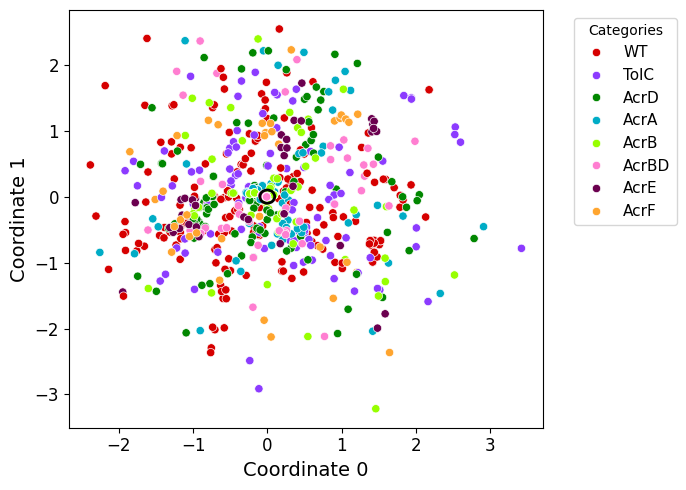

In [ ]:
# Encoding the data using the trained autoencoder
test_mean,test_logvar = model.encode(X_test_tensor3,C_test_tensor)
train_mean,train_logvar = model.encode(X_train_tensor3,C_train_tensor)
test_mean = test_mean.detach().numpy()
test_logvar = test_logvar.detach().numpy()
train_mean = train_mean.detach().numpy()
train_logvar = train_logvar.detach().numpy()

total_mean_df = pd.DataFrame(np.concatenate((test_mean, train_mean), axis=0))
total_logvar_df = pd.DataFrame(np.concatenate((test_logvar, train_logvar), axis=0))
dataset_batches = np.concatenate((batches_test, batches_train))
total_mean_df['categories'] = dataset_batches
total_mean_df['categories'] = dataset_batches

custom_palette = sns.color_palette(cc.glasbey,len(experiments2)) 
g = sns.PairGrid(total_mean_df,hue='categories',palette=custom_palette)
g.map(sns.scatterplot)
g.add_legend()

x_col = g.x_vars[0]  # The x variable for the subplot at (1, 0)
y_col = g.y_vars[1]  # The y variable for the subplot at (1, 0)
data_subset = total_mean_df[[x_col, y_col, 'categories']]

# Define points
p1 = (0, 0)
p2 = (-1.2, 0)
p3 = (-1.75, 0.4)

# Plot the extracted data in a new figure
fig, ax = plt.subplots(1,1,figsize=[7,5])
sns.scatterplot(data=data_subset, x=x_col, y=y_col, hue='categories', palette=custom_palette)

# # Add the dashed line
# x_start, x_end = -1.6, 1.40
# y_start, y_end = -1.1, 0.0
# plt.plot([x_start, x_end], [y_start, y_end], linestyle='--', color='black')

# Function to add multiple arrows along a line
def add_arrows(x_start, x_end, y_start, y_end, num_arrows=5, arrow_length=0.1):
    arrowprops = dict(facecolor='black', edgecolor='black', arrowstyle='-|>', lw=1)
    for i in np.linspace(0, 1, num_arrows, endpoint=False)[1:]:
        x = x_start + i * (x_end - x_start)
        y = y_start + i * (y_end - y_start)
        dx = (x_end - x_start) * arrow_length / np.hypot(x_end - x_start, y_end - y_start)
        dy = (y_end - y_start) * arrow_length / np.hypot(x_end - x_start, y_end - y_start)
        ax.annotate('', xy=(x + dx, y + dy), xytext=(x, y), arrowprops=arrowprops)

# # Add arrows along the dashed line
# add_arrows(x_start, x_end, y_start, y_end, num_arrows=7, arrow_length=0.15)
# # Add circles at the specified points
circle1 = plt.Circle(p1, 0.1, color='black', fill=False, linewidth=2, zorder=5)  # Adjust radius as needed
# circle2 = plt.Circle(p2, 0.1, color='black', fill=False, linewidth=2, zorder=5)
# circle3 = plt.Circle(p3, 0.1, color='black', fill=False, linewidth=2, zorder=5)
ax.add_artist(circle1)
# ax.add_artist(circle2)
# ax.add_artist(circle3)
# plt.text(p1[0]-0.11, p1[1], 'p1', fontsize=12, color='black', ha='right')
# plt.text(p2[0]-0.11, p2[1], 'p2', fontsize=12, color='black', ha='right')
# plt.text(p3[0], p3[1]+0.15, 'p3', fontsize=12, color='black', ha='right')
# plt.text(x_start-0.02, y_start, '0', fontsize=12, color='black', ha='right')
# plt.text(x_end+0.1, y_end, '9', fontsize=12, color='black', ha='right')
# Customize the plot

plt.xlabel('Coordinate 0', fontsize=14)
plt.ylabel('Coordinate 1', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
# ax.set_xticks(np.arange(-3.0, 2.1, 1.)) 
# ax.set_yticks(np.arange(-2.0, 1.6, 1.))
# Place the legend outside the plot
plt.legend(title='Categories', bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=11)
plt.tight_layout()  # Adjust layout to make room for the legend
plt.show()



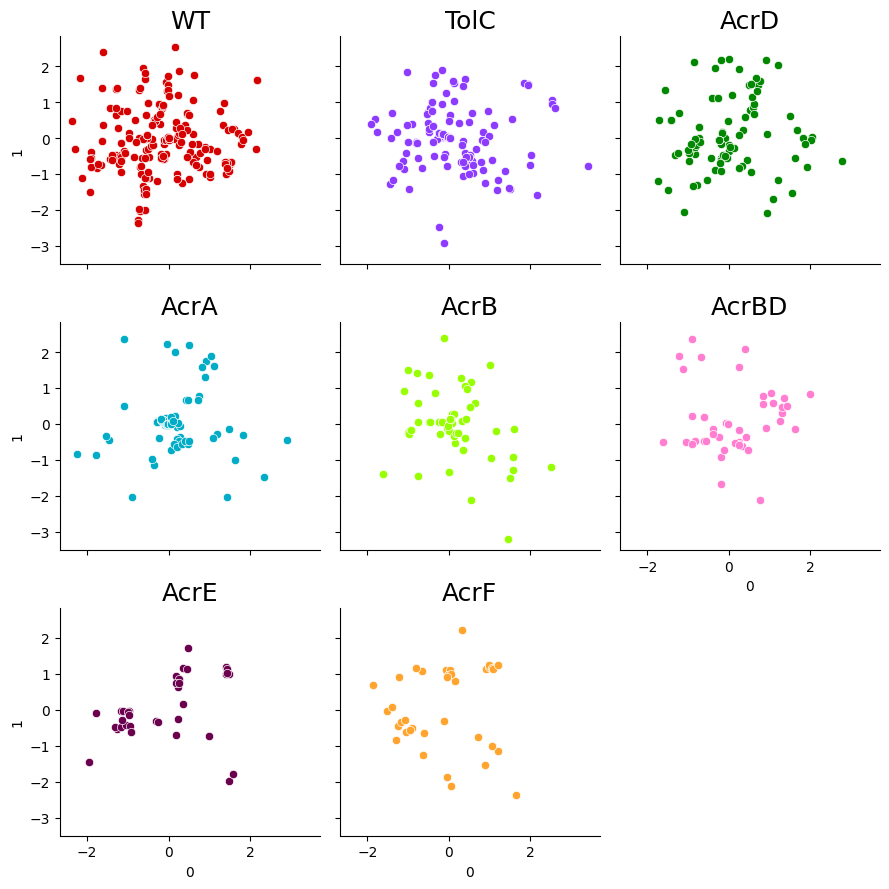

In [12]:
n_categories = data_subset['categories'].nunique()

g = sns.FacetGrid(data=data_subset,col='categories',hue='categories',palette=custom_palette,col_wrap=math.ceil(math.sqrt(n_categories))) # Optional: Use col_wrap to wrap the plots after a certain number of columns # col_wrap=3
g.map(sns.scatterplot, x_col, y_col)

# 3. Clean up the titles (optional but recommended)
# This replaces the default title (e.g., "categories = CatA")
g.set_titles(col_template="{col_name}", size=18)

# Adjust the layout to prevent titles and labels from overlapping
plt.tight_layout()
# plt.show()

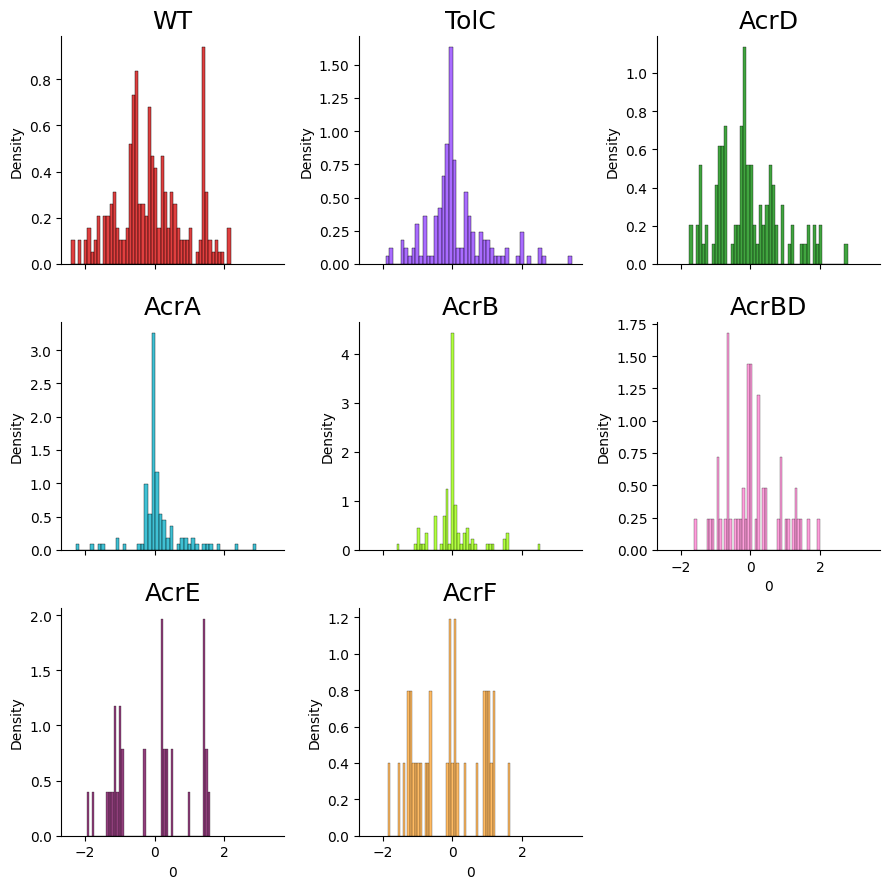

In [17]:
n_categories = data_subset['categories'].nunique()

g = sns.FacetGrid(data=data_subset,col='categories',hue='categories',palette=custom_palette,col_wrap=math.ceil(math.sqrt(n_categories)),sharey=False) # Optional: Use col_wrap to wrap the plots after a certain number of columns # col_wrap=3
g.map(sns.histplot, x_col, bins=50,stat='density',common_norm=False)

# 3. Clean up the titles (optional but recommended)
# This replaces the default title (e.g., "categories = CatA")
g.set_titles(col_template="{col_name}", size=18)

# Adjust the layout to prevent titles and labels from overlapping
plt.tight_layout()
# plt.show()

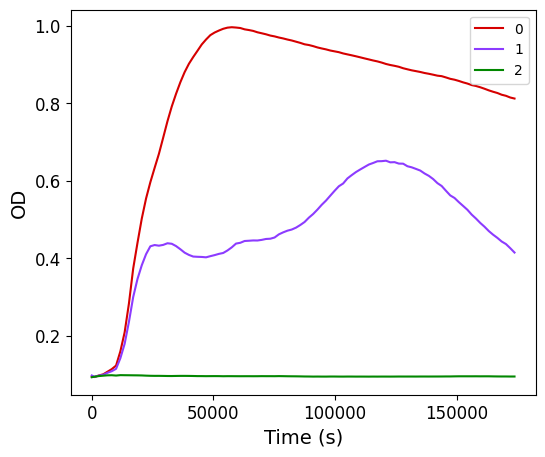

In [14]:
#Now lets see how is the generation using the Conditions
point=p1    #A point of the latent space centre
points=[point,point,point]

#The generation conditiones(strain and drug)
drug0=[1,0]  #Kanamycin [0-3.75 µg/mL], Mitomycin C [0-1.00 µg/mL] 
drug1=[1.75,0] 
drug2=[3.75,1.0] 
drug_amounts = pd.DataFrame([drug0,drug1,drug2])
strain1='WT'     #['WT', 'TolC', 'AcrD', 'AcrA', 'AcrB', 'AcrBD', 'AcrE', 'AcrF']
strain2='AcrA' 
strain3='WT'
strain1= binary_presence(strain1)
strain2= binary_presence(strain2)
strain3= binary_presence(strain3)
strains = pd.DataFrame([strain1,strain2,strain3])
C_tensor = torch.FloatTensor(pd.concat([strains,drug_amounts], axis=1).values) 
# print(C_tensor.shape)
# print(type(point))
# print(torch.FloatTensor(point).shape,torch.FloatTensor([point]).shape)
#Decoding the data using the trained autoencoder 
decoded_points= model.decode(torch.FloatTensor(points),C_tensor).detach().numpy()

#Transpose it in order to plot 
decoded_points=pd.DataFrame(decoded_points).T
decoded_points['Time [s]'] = Time

fig, ax = plt.subplots(1,1,figsize=[6,5])

#Plot the decoded vectors
palette2=sns.color_palette(cc.glasbey,len(points))
for column, color in zip(decoded_points.columns.values[:len(points)],palette2):
    sns.lineplot(data=decoded_points, x='Time [s]', y=column, ax=ax, color=color, label=column)

plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('OD', fontsize=14)
ax.set_xticks(range(0, 175000, 50000))
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()

0    0.001175
1    0.000475
dtype: float32 0    0.765143
1    0.667735
dtype: float32


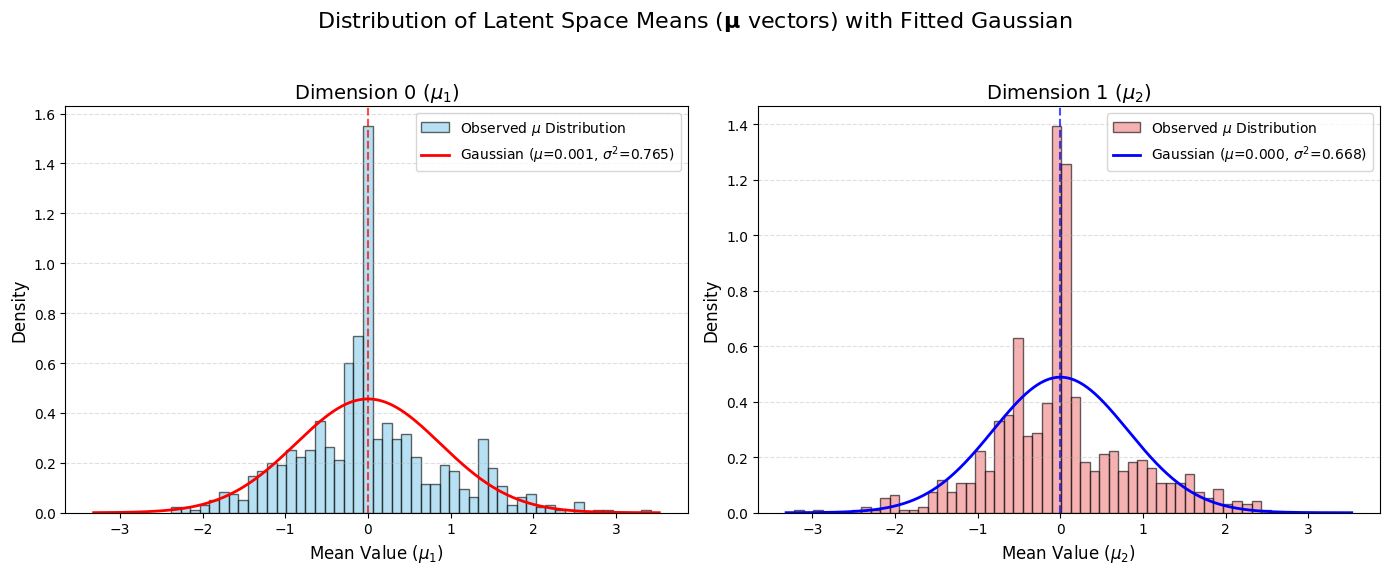

In [18]:
total_mean_df = pd.DataFrame(np.concatenate((test_mean, train_mean), axis=0))
total_logvar_df = pd.DataFrame(np.concatenate((test_logvar, train_logvar), axis=0))
mean_of_means=total_mean_df.mean()
mean_of_variances=np.exp(total_logvar_df).mean()
latentspace_variance=1-mean_of_variances
print(mean_of_means,latentspace_variance)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(r'Distribution of Latent Space Means ($\mathbf{\mu}$ vectors) with Fitted Gaussian', fontsize=16)
x_range = np.linspace(total_mean_df.min().min() - 0.1, total_mean_df.max().max() + 0.1, 1000)

# Plot for Dimension 1
dim = 0
mu = mean_of_means[dim]
sigma = np.sqrt(latentspace_variance[dim])
# Plot the Histogram 
axes[0].hist(total_mean_df.iloc[:, dim], bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black', label=r'Observed $\mu$ Distribution')
pdf = norm.pdf(x_range, mu, sigma)  #Plot the Fitted Gaussian Line
# Use 'fr' prefix to treat as a raw string AND enable f-string substitution
axes[0].plot(x_range, pdf, 'r-', linewidth=2, label=fr'Gaussian ($\mu$={mu:.3f}, $\sigma^2$={latentspace_variance[dim]:.3f})') # Note the 'fr'
axes[0].axvline(mu, color='red', linestyle='dashed', linewidth=1.5, alpha=0.7)  # Vertical line
axes[0].set_title(r'Dimension 0 ($\mu_1$)', fontsize=14)
axes[0].set_xlabel(r'Mean Value ($\mu_1$)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].grid(axis='y', alpha=0.4, linestyle='--')
axes[0].legend(loc='upper right')

# Plot for Dimension 2
dim = 1
mu = mean_of_means[dim]
sigma = np.sqrt(latentspace_variance[dim])
# Plot the Histogram
axes[1].hist(total_mean_df.iloc[:, dim], bins=50, density=True, alpha=0.6, color='lightcoral', edgecolor='black', label=r'Observed $\mu$ Distribution')
pdf = norm.pdf(x_range, mu, sigma)
axes[1].plot(x_range, pdf, 'b-', linewidth=2,label=fr'Gaussian ($\mu$={mu:.3f}, $\sigma^2$={latentspace_variance[dim]:.3f})') # Note the 'fr'
axes[1].axvline(mu, color='blue', linestyle='dashed', linewidth=1.5, alpha=0.7)
axes[1].set_title(r'Dimension 1 ($\mu_2$)', fontsize=14)
axes[1].set_xlabel(r'Mean Value ($\mu_2$)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].grid(axis='y', alpha=0.4, linestyle='--')
axes[1].legend(loc='upper right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()